## data analysis (EDA)

* > 1- Top 10 selling product
* > 2- Top 10 Countries by Sales Frequency
* > 3- Peak Shopping Hours
* > 4- Revenue by Hour
* > 5- Unit Price Distribution
* > 6- The relationship between Quantity and Price
* > 7- Do people shop more on weekends?

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [4]:
rfm_final_data = pd.read_csv('rfm_final_data.csv')
rfm_final_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_price,InvoiceYear,InvoiceMonth,DayOfWeek,hour,weekend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,Wednesday,8,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Wednesday,8,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,Wednesday,8,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Wednesday,8,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Wednesday,8,0


* > 1- Top 10 selling product


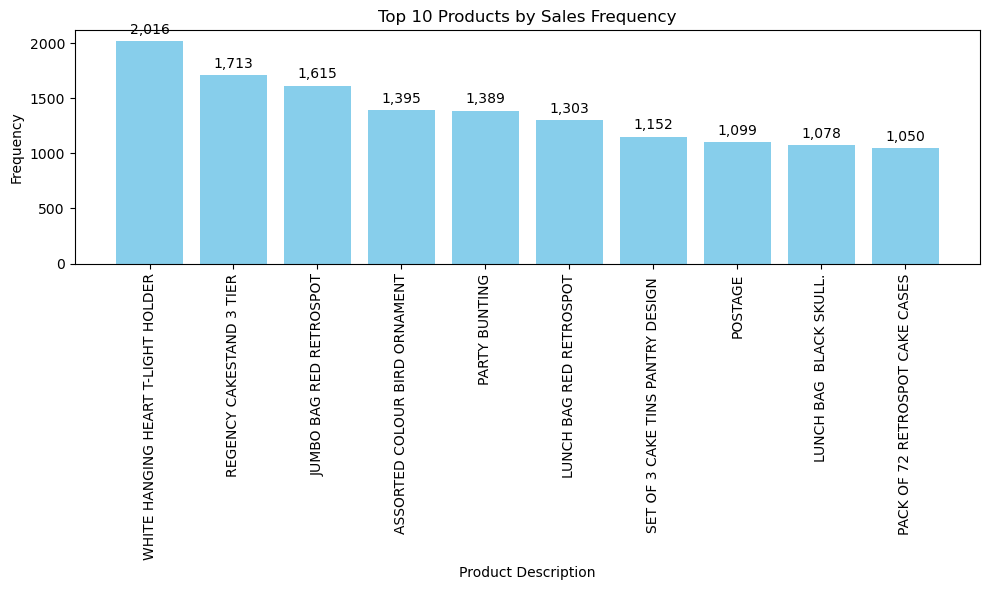

In [10]:
top_slaes = rfm_final_data['Description'].value_counts().head(10)

plt.figure(figsize=(10,6))
bars = plt.bar(top_slaes.index, top_slaes.values, color='skyblue')
plt.xlabel('Product Description')
plt.ylabel('Frequency')
plt.title('Top 10 Products by Sales Frequency')
plt.xticks(rotation=90)
plt.tight_layout()

ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom',
                xytext=(0, 3), textcoords='offset points')

plt.show()

* > 2- Top 10 Countries by Sales Frequency

In [11]:
rfm_final_data['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Finland',
       'Austria', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Israel', 'Saudi Arabia', 'Czech Republic',
       'Canada', 'Unspecified', 'Brazil', 'USA', 'European Community',
       'Bahrain', 'Malta', 'RSA'], dtype=object)

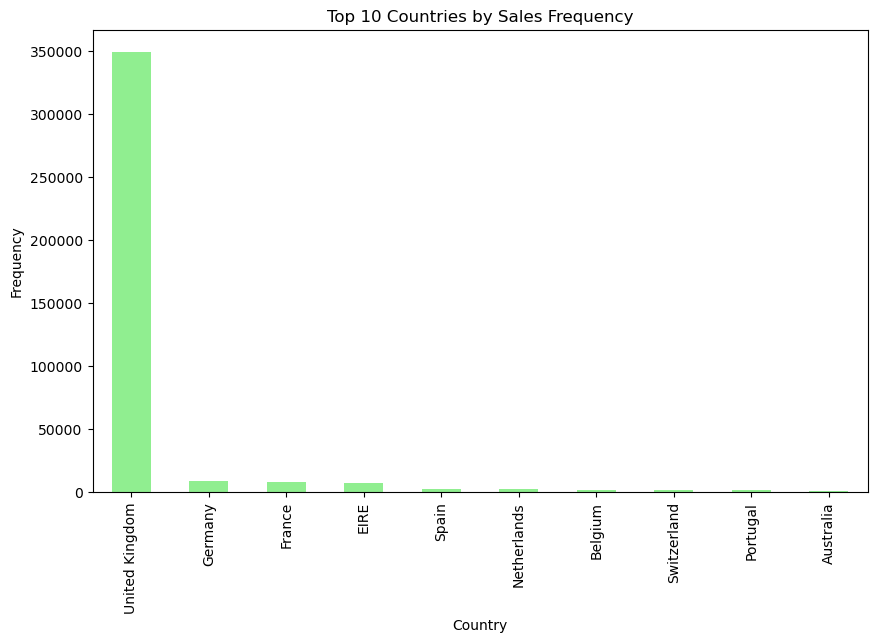

In [12]:
rfm_final_data['Country'].value_counts().head(10).plot(kind='bar', figsize=(10,6), color='lightgreen')
plt.xlabel('Country')   
plt.ylabel('Frequency')
plt.title('Top 10 Countries by Sales Frequency')
plt.show()

    

* > 3- Peak Shopping Hours

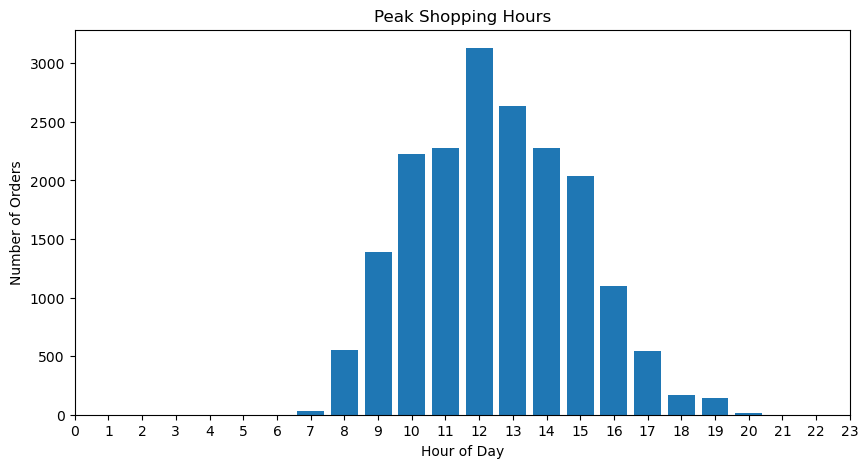

In [14]:
# Calculating the number of operations per hour
hourly_sales = rfm_final_data.groupby('hour')['InvoiceNo'].nunique()



plt.figure(figsize=(10,5))
plt.bar(hourly_sales.index, hourly_sales.values)

plt.title("Peak Shopping Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(range(0,24))
plt.show()

* > 4- Revenue by Hour

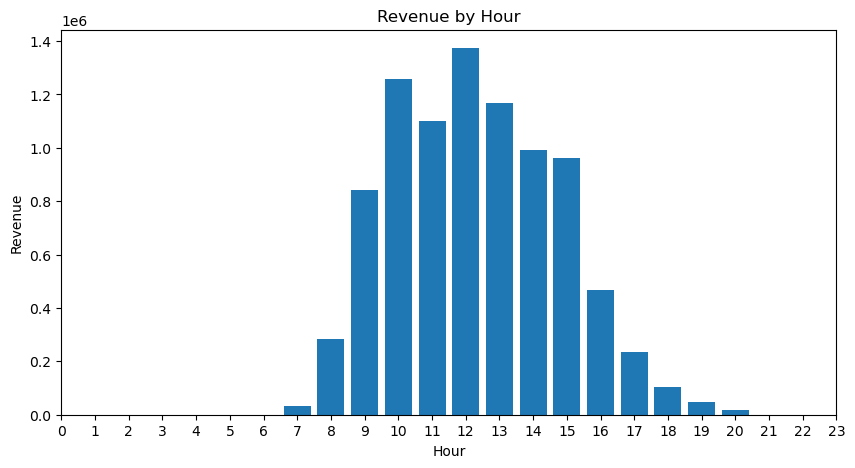

In [16]:
hourly_revenue = rfm_final_data.groupby('hour')['Total_price'].sum()

plt.figure(figsize=(10,5))
plt.bar(hourly_revenue.index, hourly_revenue.values)

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.xticks(range(0,24))
plt.show()

* > 5- Unit Price Distribution


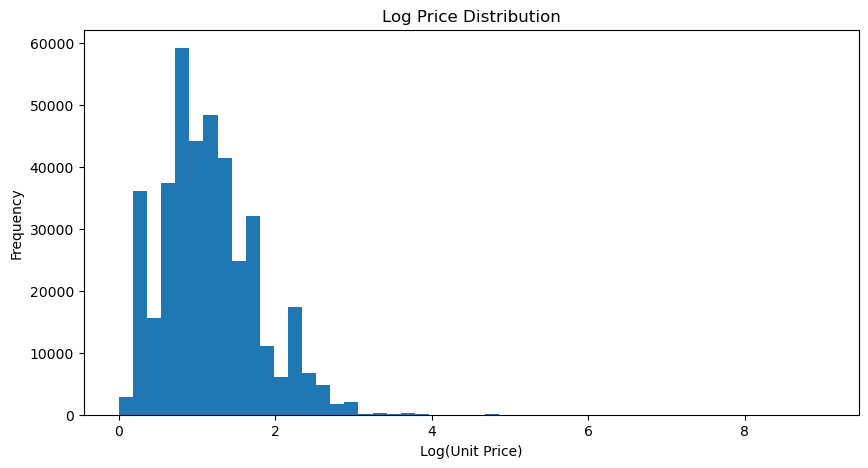

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(np.log1p(rfm_final_data['UnitPrice']), bins=50)

plt.title("Log Price Distribution")
plt.xlabel("Log(Unit Price)")
plt.ylabel("Frequency")
plt.show()

"""
To understand:

Are most products cheap or expensive?

Is there a wide range of prices?
"""

* > 6- The relationship between Quantity and Price

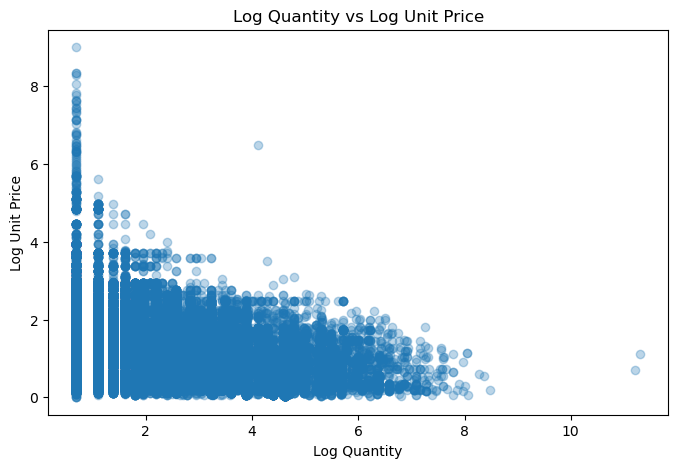

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(
    np.log1p(rfm_final_data['Quantity']),
    np.log1p(rfm_final_data['UnitPrice']),
    alpha=0.3
)

plt.title("Log Quantity vs Log Unit Price")
plt.xlabel("Log Quantity")
plt.ylabel("Log Unit Price")
plt.show()

* > 7- Do people shop more on weekends?

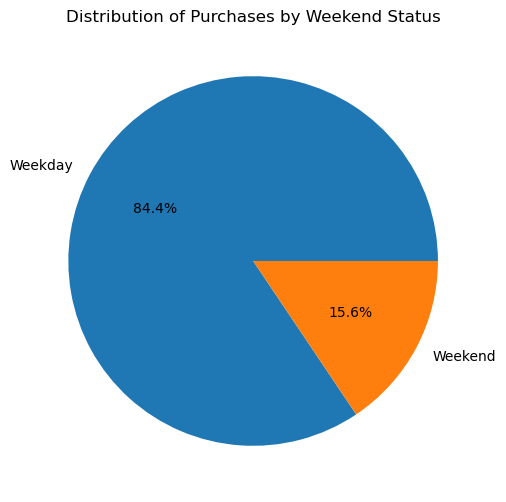

In [26]:
plt.figure(figsize=(8, 6))
plt.pie(rfm_final_data['weekend'].value_counts(), labels=['Weekday', 'Weekend'], autopct='%1.1f%%')
plt.title('Distribution of Purchases by Weekend Status')
plt.show()